In [1]:
pip install pymongo pandas scikit-learn


   ---------------------------------------- 0.0/859.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/859.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/859.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/859.2 kB ? eta -:--:--
   ------------ --------------------------- 262.1/859.2 kB ? eta -:--:--
   ------------ --------------------------- 262.1/859.2 kB ? eta -:--:--
   ----------------------- -------------- 524.3/859.2 kB 509.0 kB/s eta 0:00:01
   ----------------------- -------------- 524.3/859.2 kB 509.0 kB/s eta 0:00:01
   ---------------------------------- --- 786.4/859.2 kB 550.1 kB/s eta 0:00:01
   -------------------------------------- 859.2/859.2 kB 553.9 kB/s eta 0:00:00

   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pymongo import MongoClient
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client["HeartDiseaseDB"]
collection = db["patients"]

# 2. Load data into pandas DataFrame
df = pd.DataFrame(list(collection.find()))
df.drop(columns=["_id"], inplace=True)  # Drop MongoDB auto ID

# 3. Split features and target
X = df.drop("target", axis=1)
y = df["target"]

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Evaluate model
y_pred = model.predict(X_test)
print("✅ Model trained successfully!")
print("🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\nDetailed Report:\n", classification_report(y_test, y_pred))


✅ Model trained successfully!
🎯 Accuracy: 0.9853658536585366

Detailed Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



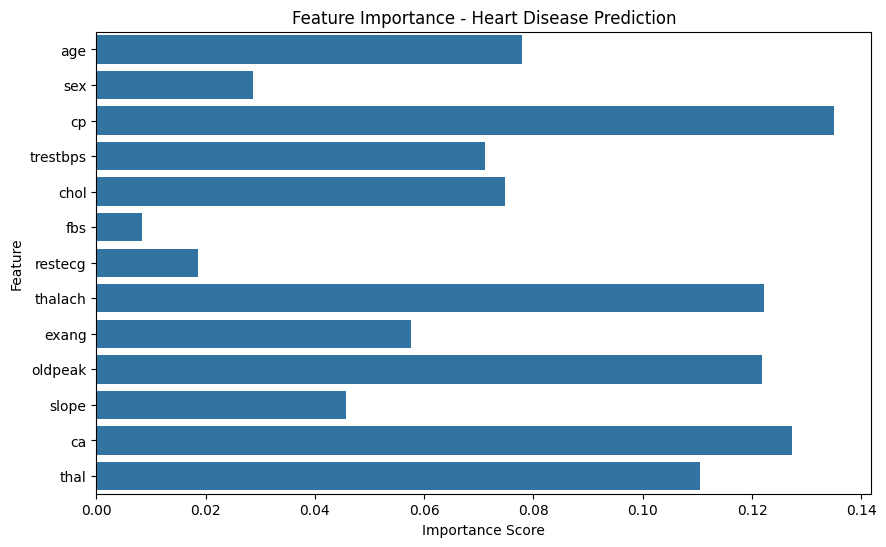

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance visualization
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Heart Disease Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("HeartDiseaseTrain-Test.csv")  # replace with your CSV path

# Optional: Check data
print(df.head())


   age     sex chest_pain_type  resting_blood_pressure  cholestoral  \
0   52    Male  Typical angina                     125          212   
1   53    Male  Typical angina                     140          203   
2   70    Male  Typical angina                     145          174   
3   61    Male  Typical angina                     148          203   
4   62  Female  Typical angina                     138          294   

      fasting_blood_sugar               rest_ecg  Max_heart_rate  \
0    Lower than 120 mg/ml  ST-T wave abnormality             168   
1  Greater than 120 mg/ml                 Normal             155   
2    Lower than 120 mg/ml  ST-T wave abnormality             125   
3    Lower than 120 mg/ml  ST-T wave abnormality             161   
4  Greater than 120 mg/ml  ST-T wave abnormality             106   

  exercise_induced_angina  oldpeak        slope vessels_colored_by_flourosopy  \
0                      No      1.0  Downsloping                           Two   
1 

In [6]:
# Convert dataframe to JSON records
data = df.to_dict(orient='records')


In [7]:
from pymongo import MongoClient

# Connect to local MongoDB (default port 27017)
client = MongoClient("mongodb://localhost:27017/")

# Create database and collection
db = client["heart_db"]             # Database name
collection = db["heart_data"]       # Collection name


In [8]:
# Insert all records at once
collection.insert_many(data)

print("Dataset inserted into MongoDB successfully!")


Dataset inserted into MongoDB successfully!


In [9]:
# Fetch first 5 documents
for doc in collection.find().limit(5):
    print(doc)


{'_id': ObjectId('690db3bde3d6e6059d3dd388'), 'age': 52, 'sex': 'Male', 'chest_pain_type': 'Typical angina', 'resting_blood_pressure': 125, 'cholestoral': 212, 'fasting_blood_sugar': 'Lower than 120 mg/ml', 'rest_ecg': 'ST-T wave abnormality', 'Max_heart_rate': 168, 'exercise_induced_angina': 'No', 'oldpeak': 1.0, 'slope': 'Downsloping', 'vessels_colored_by_flourosopy': 'Two', 'thalassemia': 'Reversable Defect', 'target': 0}
{'_id': ObjectId('690db3bde3d6e6059d3dd389'), 'age': 53, 'sex': 'Male', 'chest_pain_type': 'Typical angina', 'resting_blood_pressure': 140, 'cholestoral': 203, 'fasting_blood_sugar': 'Greater than 120 mg/ml', 'rest_ecg': 'Normal', 'Max_heart_rate': 155, 'exercise_induced_angina': 'Yes', 'oldpeak': 3.1, 'slope': 'Upsloping', 'vessels_colored_by_flourosopy': 'Zero', 'thalassemia': 'Reversable Defect', 'target': 0}
{'_id': ObjectId('690db3bde3d6e6059d3dd38a'), 'age': 70, 'sex': 'Male', 'chest_pain_type': 'Typical angina', 'resting_blood_pressure': 145, 'cholestoral': 

In [10]:
# Create index on commonly queried fields
collection.create_index("age")
collection.create_index("target")


'target_1'

In [14]:
# ========================================
# Step 1: Import libraries
# ========================================
import pandas as pd
from pymongo import MongoClient
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


In [15]:
# ========================================
# Step 2: Connect to MongoDB and read data
# ========================================
client = MongoClient("mongodb://localhost:27017/")  # Change if using remote DB
db = client["heart_db"]                              # Database name
collection = db["heart_data"]                        # Collection name

# Fetch all documents
data = list(collection.find())
df = pd.json_normalize(data)

# Drop MongoDB default '_id' column if exists
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

print("Dataset loaded. First 5 rows:")
df.head()


Dataset loaded. First 5 rows:


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [24]:
# ========================================
# Step 3: Data Cleaning
# ========================================

# ========================================
# Step 3: Data Cleaning
# ========================================

# 3.1 Convert 'vessels_colored_by_flourosopy' from strings to numeric
vessel_mapping = {'Zero': 0, 'One': 1, 'Two': 2, 'Three': 3}
df['vessels_colored_by_flourosopy'] = df['vessels_colored_by_flourosopy'].map(vessel_mapping)

# Handle any unexpected values that were not mapped
df['vessels_colored_by_flourosopy'] = df['vessels_colored_by_flourosopy'].fillna(0).astype(int)

# 3.2 Fill missing numeric values with mean
numeric_cols = ['age', 'resting_blood_pressure', 'cholestoral', 
                'Max_heart_rate', 'oldpeak', 'vessels_colored_by_flourosopy']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # ensure numeric type
    df[col] = df[col].fillna(df[col].mean())

# 3.3 Fill missing categorical values with mode
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 
                    'rest_ecg', 'exercise_induced_angina', 'slope', 
                    'thalassemia']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# 3.4 Final check for missing values
print("Missing values after cleaning:")
print(df.isna().sum())


Missing values after cleaning:
age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [25]:
# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Convert categorical columns to numeric using one-hot encoding
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 
                    'rest_ecg', 'exercise_induced_angina', 'slope', 'thalassemia']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Standardize numeric columns
numeric_cols = ['age', 'resting_blood_pressure', 'cholestoral', 
                'Max_heart_rate', 'oldpeak', 'vessels_colored_by_flourosopy']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X.head()


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,vessels_colored_by_flourosopy,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,fasting_blood_sugar_Lower than 120 mg/ml,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,0.0,True,False,False,True,True,False,True,False,False,False,False,False,True
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,0.0,True,False,False,True,False,True,False,True,False,True,False,False,True
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,0.0,True,False,False,True,True,False,True,True,False,True,False,False,True
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.0,True,False,False,True,True,False,True,False,False,False,False,False,True
4,0.834359,0.364875,0.930822,-1.874977,0.705408,0.0,False,False,False,True,False,False,True,False,True,False,False,False,False


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (820, 19)
X_test shape: (205, 19)


In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [28]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7804878048780488

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.77      0.78       102
           1       0.78      0.79      0.78       103

    accuracy                           0.78       205
   macro avg       0.78      0.78      0.78       205
weighted avg       0.78      0.78      0.78       205



In [29]:
# ========================================
# Step 6: Train Random Forest Classifier
# ========================================
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # Number of trees
    max_depth=None,          # No maximum depth (grow until pure)
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model training completed.")


Random Forest model training completed.


In [30]:
# ========================================
# Step 7: Evaluate Random Forest
# ========================================
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



In [31]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_model, X, y, cv=5)  # 5-fold CV
print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())


Cross-validation scores: [1.         1.         0.98536585 1.         0.98536585]
Mean CV accuracy: 0.9941463414634146


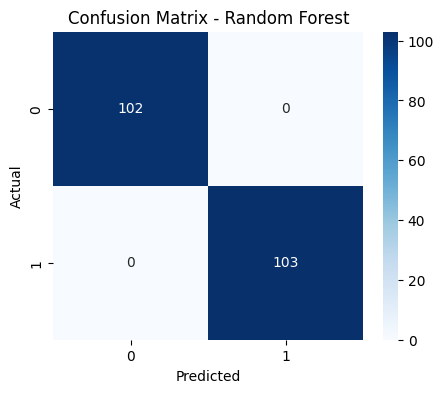

In [32]:
# ========================================
# Confusion Matrix
# ========================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


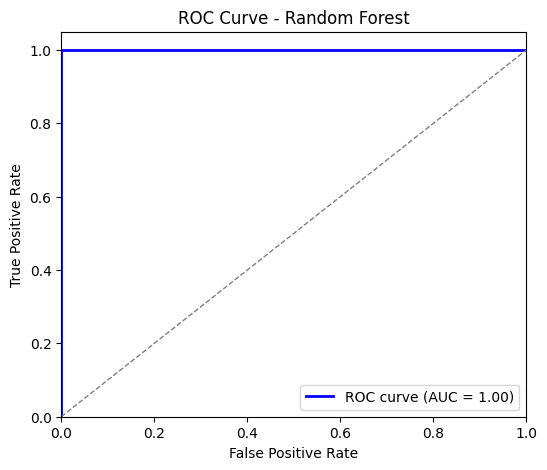

In [33]:
# ========================================
# ROC Curve & AUC
# ========================================
from sklearn.metrics import roc_curve, auc

# Get probabilities for positive class
y_prob = rf_model.predict_proba(X_test)[:,1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()


C:\Users\shash\AppData\Local\Temp\ipykernel_23596\1228971351.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')


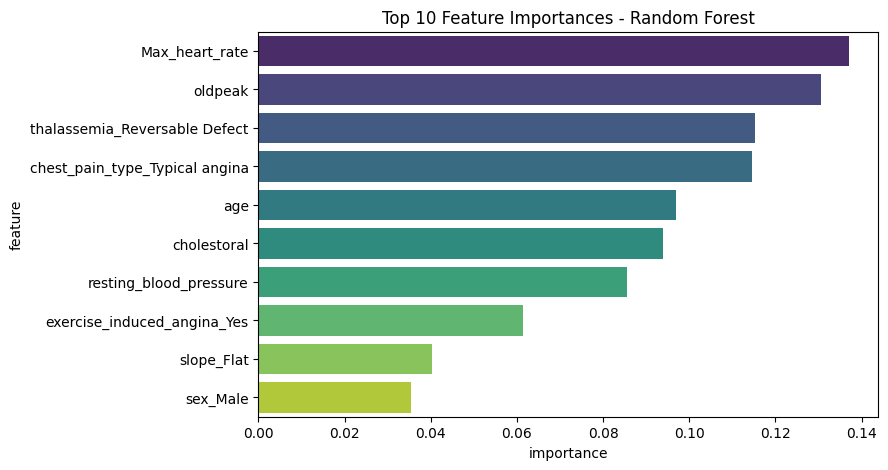

In [34]:
# ========================================
# Feature Importance
# ========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_model.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({'feature': features, 'importance': importances})
feat_df = feat_df.sort_values(by='importance', ascending=False).head(10)  # top 10 features

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis')
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()


In [13]:
# Step 1: Import libraries
import pandas as pd
from pymongo import MongoClient
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib  # For saving the model


In [14]:
# Step 2: Connect to MongoDB
client = MongoClient("mongodb://localhost:27017/")  # Update if remote
db = client["heart_db"]
collection = db["heart_data"]

# Load all documents into a DataFrame
data = list(collection.find())
df = pd.json_normalize(data)

# Drop MongoDB default _id column
if '_id' in df.columns:
    df = df.drop(columns=['_id'])

# Preview dataset
df.head()


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,2,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,0,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,0,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,1,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,3,Fixed Defect,0


In [15]:
# Step 3: Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# List of categorical and numeric columns
categorical_cols = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 
                    'rest_ecg', 'exercise_induced_angina', 'slope', 'thalassemia']
numeric_cols = ['age', 'resting_blood_pressure', 'cholestoral', 
                'Max_heart_rate', 'oldpeak', 'vessels_colored_by_flourosopy']


In [16]:
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X.head()


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,vessels_colored_by_flourosopy,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,fasting_blood_sugar_Lower than 120 mg/ml,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,1.0,2,True,False,False,True,True,False,True,False,False,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,True,False,True,False,True,False,True,False,False,True
2,70,145,174,125,2.6,0,True,False,False,True,True,False,True,True,False,True,False,False,True
3,61,148,203,161,0.0,1,True,False,False,True,True,False,True,False,False,False,False,False,True
4,62,138,294,106,1.9,3,False,False,False,True,False,False,True,False,True,False,False,False,False


In [17]:
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X.head()


,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,vessels_colored_by_flourosopy,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,fasting_blood_sugar_Lower than 120 mg/ml,rest_ecg_Normal,rest_ecg_ST-T wave abnormality,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,-0.268437,-0.377636,-0.659332,0.821321,-0.060888,1.209221,True,False,False,True,True,False,True,False,False,False,False,False,True
1,-0.158157,0.479107,-0.833861,0.255968,1.727137,-0.731971,True,False,False,True,False,True,False,True,False,True,False,False,True
2,1.716595,0.764688,-1.396233,-1.048692,1.301417,-0.731971,True,False,False,True,True,False,True,True,False,True,False,False,True
3,0.724079,0.936037,-0.833861,0.516900,-0.912329,0.238625,True,False,False,True,True,False,True,False,False,False,False,False,True
4,0.834359,0.364875,0.930822,-1.874977,0.705408,2.179817,False,False,False,True,False,False,True,False,True,False,False,False,False


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [20]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Accuracy: 0.9853658536585366

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Cross-validation scores: [1.         1.         1.         1.         0.98536585]
Mean CV accuracy: 0.9970731707317073


In [21]:
# Save model to disk
joblib.dump(model, "random_forest_heart_model.pkl")
print("Model saved as random_forest_heart_model.pkl")


Model saved as random_forest_heart_model.pkl


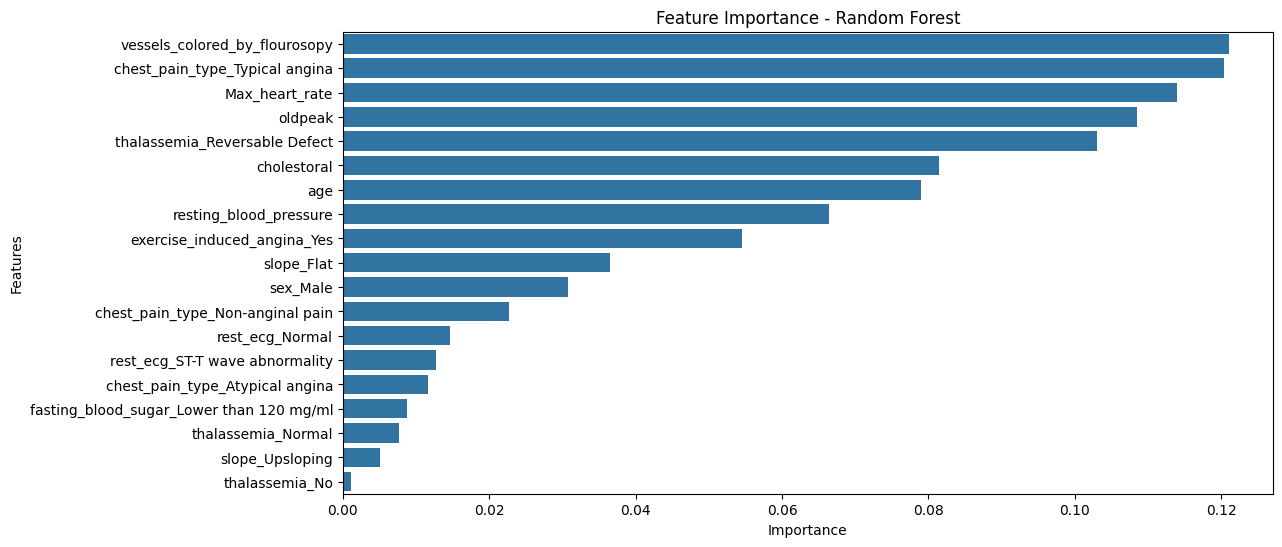

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from the trained Random Forest model
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


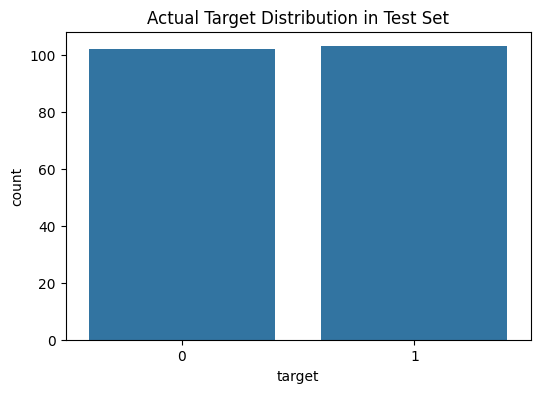

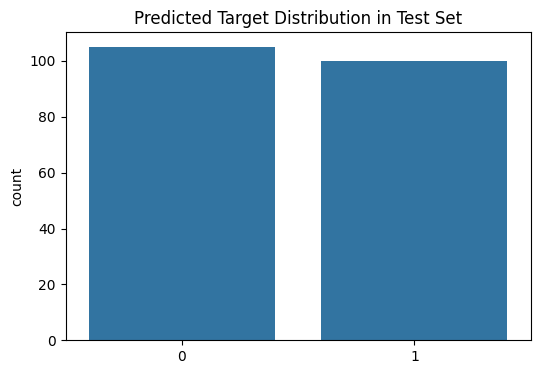

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_test)
plt.title("Actual Target Distribution in Test Set")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title("Predicted Target Distribution in Test Set")
plt.show()


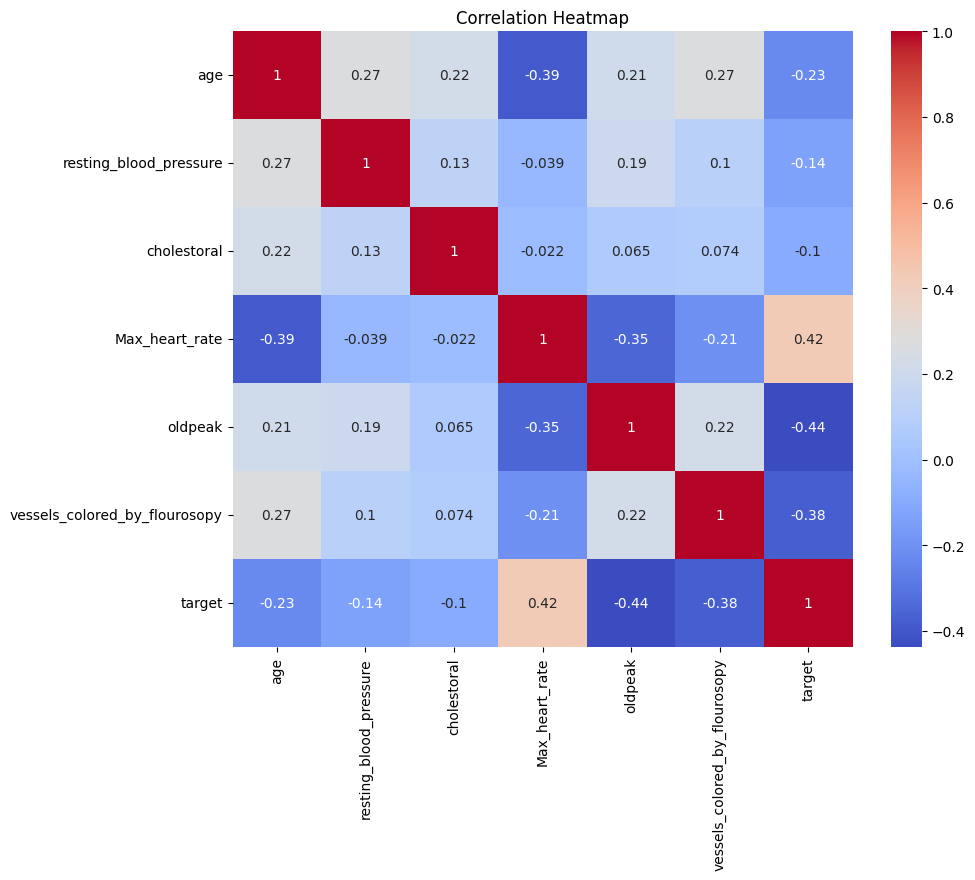

In [53]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols + ['target']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


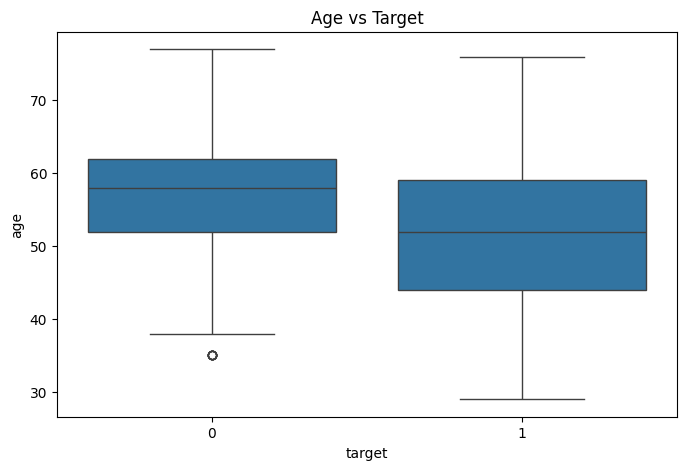

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Target")
plt.show()


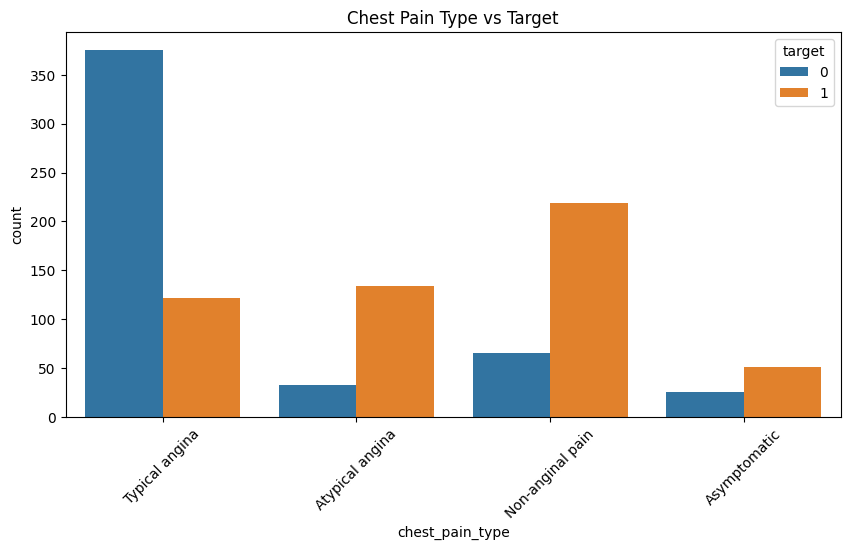

In [55]:
plt.figure(figsize=(10,5))
sns.countplot(x='chest_pain_type', hue='target', data=df)
plt.title("Chest Pain Type vs Target")
plt.xticks(rotation=45)
plt.show()


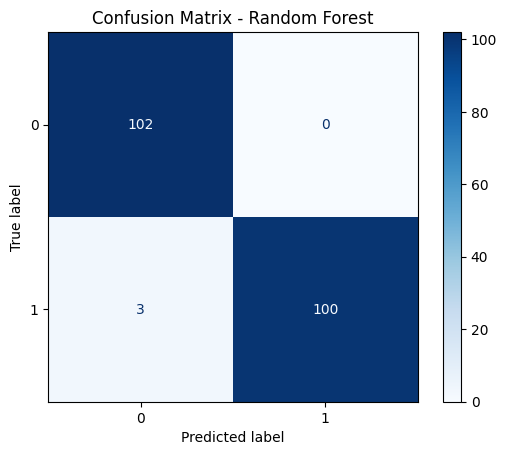

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()
